In [ ]:
#!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data  test.jpg


In [ ]:
import os
import numpy as np
import matplotlib.image as mping
import cv2
from google.colab.patches import cv2_imshow
from PIL  import Image

In [ ]:
with_mask=os.listdir('/content/data/with_mask')
without_mask=os.listdir('/content/data/without_mask')

In [ ]:
print('the number of with mask images :',len(with_mask))
print('the number of without mask images :',len(without_mask))

the number of with mask images : 3725
the number of without mask images : 3828


In [ ]:
with_mask_labels = [1]*len(with_mask)
without_mask_labels = [0]*len(without_mask)

In [ ]:
labels = with_mask_labels + without_mask_labels
len(labels)

7553

In [ ]:
with_mask_path = '/content/data/with_mask/'
without_mask_path = '/content/data/without_mask/'
data=[]
for img_file in with_mask:
  img = Image.open(with_mask_path+img_file)
  img = img.resize((128,128))
  img = img.convert('RGB')
  img = np.array(img)
  data.append(img)
for img_file in without_mask:
  img = Image.open(without_mask_path+img_file)
  img = img.resize((128,128))
  img = img.convert('RGB')
  img = np.array(img)
  data.append(img)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
X =np.array(data)
y = np.array(labels)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

# **CNN Model**

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout,BatchNormalization,RandomFlip,RandomRotation,RandomZoom

In [ ]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])
model = Sequential()
model.add(data_augmentation)
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])
history = model.fit(X_train_scaled,y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - acc: 0.6811 - loss: 0.6443 - val_acc: 0.8843 - val_loss: 0.3044
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.8618 - loss: 0.3624 - val_acc: 0.8860 - val_loss: 0.2811
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - acc: 0.8749 - loss: 0.3232 - val_acc: 0.8793 - val_loss: 0.3035
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - acc: 0.8858 - loss: 0.2952 - val_acc: 0.9074 - val_loss: 0.2315
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.8927 - loss: 0.2680 - val_acc: 0.9157 - val_loss: 0.2002


In [ ]:
print(model.evaluate(X_train_scaled,y_train))
print(model.evaluate(X_test_scaled,y_test))

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - acc: 0.9207 - loss: 0.1942
[0.1901446282863617, 0.9190665483474731]
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9159 - loss: 0.1838
[0.19926738739013672, 0.911316990852356]


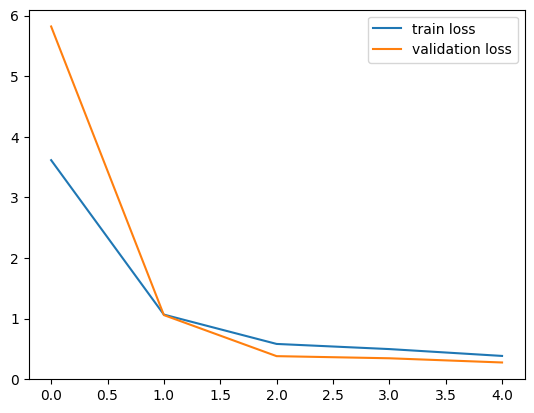

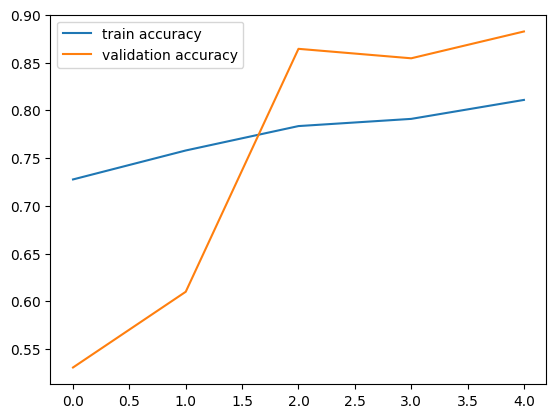

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()
plt.plot(history.history['acc'],label='train accuracy')
plt.plot(history.history['val_acc'],label='validation accuracy')
plt.legend()
plt.show()

In [ ]:
def predict_mask(image_path, model):
    img = cv2.imread(image_path)
    cv2_imshow(img)
    img_resized = cv2.resize(img, (128, 128))
    img_scaled = img_resized / 255.0
    img_reshaped = np.reshape(img_scaled, (1, 128, 128, 3))
    prediction = model.predict(img_reshaped)
    label = np.argmax(prediction)
    if label == 1:
        return "The person is wearing a mask"
    else:
        return "The person is not wearing a mask"

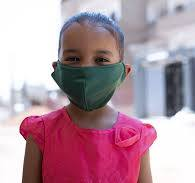

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
The person is wearing a mask


In [ ]:
result = predict_mask("test.jpg", model)
print(result)